# Eigenvalue Analysis on Large-Dimensional Matrices

## 📚 Learning Objectives

By completing this notebook, you will:
- Solve eigenvalue problems programmatically for large matrices
- Apply eigenvalue analysis on large-dimensional matrices
- Understand the importance of eigenvalues in ML
- Apply eigenvalue decomposition to real ML problems

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 1, lesson 03 "Eigenvalues and Eigenvectors" — the same decomposition, now at a size where computing all of it is the wrong plan.

**Used later in:** Course 04 (AIAT 114) — Unit 4, lesson 03 "Principal Component Analysis (PCA)" — `PCA(n_components=2)` is this truncated decomposition, done for you.

---

This notebook covers practical activities from **Course 03, Unit 1**:
- Solving eigenvalue problems programmatically and applying eigenvalue analysis on large-dimensional matrices

---

## Introduction

**Eigenvalue analysis** is crucial for understanding matrix properties and is fundamental in machine learning for dimensionality reduction, principal component analysis, and understanding model behavior.


---

## 📌 Real case: the algorithm scikit-learn switches to behind your back

Read scikit-learn's own documentation for `PCA(svd_solver="auto")` and you find a rule, not a promise:
"if the input data is larger than 500×500 and the number of components to extract is lower than 80% of the
smallest dimension of the data, then the more efficient **randomized** method is selected." That randomized
method is the algorithm of Halko, Martinsson and Tropp, *"Finding Structure with Randomness"* (SIAM Review
53(2), 2011) — cited by name in the docs and listed in this notebook's references. It does not compute the
eigen-decomposition. It computes an *approximation* of the top few directions, with a probabilistic accuracy
guarantee, because on a large matrix the exact answer is not affordable and, for the top-k question, not
needed.

So the library you will use has already conceded the point this notebook is about: **on large matrices, how
you ask for eigenvalues matters more than the fact that you asked.** Part 1 below makes the same concession
visible at small scale — `scipy.linalg.eigh` beats `np.linalg.eig` by roughly 7× on a 200×200 matrix, purely
because it is told the matrix is symmetric.

**What goes wrong without this.** Call `np.linalg.eig` on a 20,000×20,000 covariance matrix and you have
asked for 20,000 eigenvalues when you wanted 10, at a cost that scales like n³. The job does not fail; it
runs until your session dies. Knowing which solver matches which structure is the difference between a
2-millisecond answer and no answer.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: NumPy/Matplotlib plus SciPy's eigh (fast symmetric eigensolver), sklearn's PCA for the
# ML tie-in, and the real handwritten-digits dataset that supplies every matrix in this notebook.

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits

# Confirm the environment is ready before any math starts.
print("✅ Libraries imported!")
print("\nEigenvalue Analysis on Large-Dimensional Matrices")
print("=" * 60)


✅ Libraries imported!

Eigenvalue Analysis on Large-Dimensional Matrices


## Part 1: Computing Eigenvalues for Large Matrices


In [2]:
# Eigendecompose a real 200x200 symmetric matrix two ways and verify Av = lambda*v.
# eigh() exploits symmetry - the shortcut you should reach for on covariance and kernel matrices.

import time

print("=" * 60)
print("Part 1: Computing Eigenvalues for Large Matrices")
print("=" * 60)

# Where do large symmetric matrices actually come from in ML? Two places dominate:
# covariance matrices (Part 2) and Gram/kernel matrices (here).
# A Gram matrix G[i, j] = <x_i, x_j> records how similar every pair of samples is.
# It is symmetric by construction, so its eigenvalues are guaranteed real.

digits = load_digits()  # 1797 real handwritten digit images, each 8x8 = 64 pixels
print(f"\nDataset: sklearn digits - {digits.data.shape[0]} images, {digits.data.shape[1]} pixels each")

n = 200  # take the first 200 images -> a 200x200 Gram matrix
X_sub = digits.data[:n]
X_sub = X_sub - X_sub.mean(axis=0)          # center, so the Gram matrix is scatter-like
A_symmetric = X_sub @ X_sub.T               # real, symmetric, positive semi-definite

print(f"Gram matrix built from real images: {A_symmetric.shape}")
print(f"Symmetric? max|G - G^T| = {np.max(np.abs(A_symmetric - A_symmetric.T)):.2e}")

print(f"\nComputing eigenvalues for the {n}x{n} matrix...")

# Full (general-purpose) eigenvalue decomposition
t0 = time.perf_counter()
eigenvalues_full, eigenvectors_full = np.linalg.eig(A_symmetric)
t_eig = time.perf_counter() - t0
eigenvalues_full = np.real(eigenvalues_full)  # symmetric input -> imaginary parts are numerical dust
print(f"np.linalg.eig  -> {len(eigenvalues_full)} eigenvalues in {t_eig * 1000:.1f} ms")
print(f"  Largest 5: {np.sort(eigenvalues_full)[::-1][:5].round(2)}")

# For symmetric matrices, use the specialized routine
t0 = time.perf_counter()
eigenvalues_sym, eigenvectors_sym = eigh(A_symmetric)
t_eigh = time.perf_counter() - t0
print(f"\nscipy eigh     -> same job in {t_eigh * 1000:.1f} ms "
      f"({t_eig / max(t_eigh, 1e-9):.1f}x faster, and it returns sorted, real results)")
print(f"  Largest 5: {eigenvalues_sym[::-1][:5].round(2)}")

# Verify: Av = lambda*v  (take the LAST index: eigh sorts ascending, so that is the largest)
idx = -1
v = eigenvectors_sym[:, idx]
lambda_val = eigenvalues_sym[idx]
Av = A_symmetric @ v
lambda_v = lambda_val * v

print("\nVerification (Av = lambda*v) for the top eigenpair:")
print(f"  lambda = {lambda_val:.4f}")
print(f"  Max difference: {np.max(np.abs(Av - lambda_v)):.2e}")

print("\n✅ Eigenvalues computed for a large REAL symmetric matrix!")


Part 1: Computing Eigenvalues for Large Matrices

Dataset: sklearn digits - 1797 images, 64 pixels each
Gram matrix built from real images: (200, 200)
Symmetric? max|G - G^T| = 0.00e+00

Computing eigenvalues for the 200x200 matrix...
np.linalg.eig  -> 200 eigenvalues in 10.5 ms
  Largest 5: [42218.43 34475.75 32281.71 23035.38 19114.9 ]

scipy eigh     -> same job in 2.7 ms (3.8x faster, and it returns sorted, real results)
  Largest 5: [42218.43 34475.75 32281.71 23035.38 19114.9 ]

Verification (Av = lambda*v) for the top eigenpair:
  lambda = 42218.4339
  Max difference: 1.75e-11

✅ Eigenvalues computed for a large REAL symmetric matrix!


### 🧪 How fast does the cost actually grow?

Part 1 timed one 200×200 matrix. The limits section below claims eigendecomposition costs on the order of
n³ — so let us measure it. Baseline: `np.linalg.eig`. Change one thing: `scipy.linalg.eigh`, which is told
the matrix is symmetric. Then change the size. Measure: wall-clock time, and the factor by which it grows
each time n doubles (n³ predicts about 8×).

In [3]:
# Comparative experiment: two solvers, five matrix sizes, all built from real digit images.

sizes = [100, 200, 400, 800, 1600]
prev_eig = prev_eigh = None

print(f"{'n':>5} {'np.linalg.eig':>16} {'scipy eigh':>14} {'eigh speed-up':>15} "
      f"{'eig growth':>12} {'eigh growth':>12}")
print("-" * 80)
for n_i in sizes:
    Xi = digits.data[:n_i] - digits.data[:n_i].mean(axis=0)
    G = Xi @ Xi.T                       # n_i x n_i, real and symmetric by construction

    t0 = time.perf_counter(); np.linalg.eig(G); t_e = time.perf_counter() - t0
    t0 = time.perf_counter(); eigh(G);          t_h = time.perf_counter() - t0

    ge = f"{t_e / prev_eig:>11.1f}x" if prev_eig else f"{'-':>12}"
    gh = f"{t_h / prev_eigh:>11.1f}x" if prev_eigh else f"{'-':>12}"
    print(f"{n_i:>5} {t_e * 1000:>13.1f} ms {t_h * 1000:>11.1f} ms {t_e / max(t_h, 1e-9):>14.1f}x {ge} {gh}")
    prev_eig, prev_eigh = t_e, t_h

print()
print("Read the growth columns honestly. Textbook complexity for eigendecomposition is O(n^3), so")
print("doubling n should multiply the work by 8. The measured factors are smaller than that, and")
print("that gap is itself the lesson: at these sizes the run is dominated by memory traffic and")
print("fixed overheads, not by arithmetic, and LAPACK is heavily optimised for exactly this range.")
print("Big-O is a statement about the LIMIT, not a prediction for the sizes on your laptop - the")
print("factors here climb toward 8 as n grows, and only reach it well beyond this table.")
print()
print("What is not in doubt is the direction. Even at a growth factor of 4 per doubling, going from")
print("800 to 20,000 (a factor of 25 in n) multiplies the work enormously, and the matrix alone")
print("needs 20000^2 x 8 bytes = 3.2 GB in float64. That is why 'just compute the eigenvalues'")
print("stops being a plan at scale, and why scikit-learn's PCA switches to a randomized algorithm")
print("on large inputs instead of doing what this cell does.")

    n    np.linalg.eig     scipy eigh   eigh speed-up   eig growth  eigh growth
--------------------------------------------------------------------------------
  100           3.0 ms         0.6 ms            5.4x            -            -
  200          10.2 ms         1.4 ms            7.3x         3.3x         2.5x
  400          38.0 ms         5.5 ms            6.9x         3.7x         3.9x


  800         183.5 ms        24.7 ms            7.4x         4.8x         4.5x


 1600         783.8 ms       186.3 ms            4.2x         4.3x         7.6x

Read the growth columns honestly. Textbook complexity for eigendecomposition is O(n^3), so
doubling n should multiply the work by 8. The measured factors are smaller than that, and
that gap is itself the lesson: at these sizes the run is dominated by memory traffic and
fixed overheads, not by arithmetic, and LAPACK is heavily optimised for exactly this range.
Big-O is a statement about the LIMIT, not a prediction for the sizes on your laptop - the
factors here climb toward 8 as n grows, and only reach it well beyond this table.

What is not in doubt is the direction. Even at a growth factor of 4 per doubling, going from
800 to 20,000 (a factor of 25 in n) multiplies the work enormously, and the matrix alone
needs 20000^2 x 8 bytes = 3.2 GB in float64. That is why 'just compute the eigenvalues'
stops being a plan at scale, and why scikit-learn's PCA switches to a randomized algorithm
on large inputs instead

## Part 2: Eigenvalue Analysis for Dimensionality Reduction

> 🔭 **Preview of PCA**: Parts 2-3 walk through what is essentially Principal Component Analysis, taught fully in **Unit 4**. Here we only care about the *eigenvalue mechanics* — how the eigenvalues of a covariance matrix rank directions by importance.

**Two-line recap** (variance and covariance are formally taught in Unit 3, notebook 03):
- **Variance** measures how spread out one feature is; **covariance** measures how two features vary together.
- The **covariance matrix** collects all pairwise covariances of a dataset; its eigenvalues tell how much variance lies along each principal direction.


In [4]:
# Eigen-analysis of a covariance matrix: the seed of PCA.
# Sorting eigenvalues shows how much variance each direction holds - and how few directions really matter.

print("\n" + "=" * 60)
print("Part 2: Eigenvalue Analysis for Dimensionality Reduction")
print("=" * 60)

# Eigenvalues are fundamental for PCA (Principal Component Analysis)
# PCA uses eigenvalue decomposition of the covariance matrix.
#
# Real high-dimensional data: all 1797 digit images, each one a 64-dimensional
# vector of pixel intensities (0-16). Neighbouring pixels are strongly correlated
# in real handwriting, which is exactly why so few eigen-directions will be needed.
X = digits.data
feature_note = "64 pixel intensities per image"

print(f"\nOriginal data shape: {X.shape}  ({X.shape[0]} images, {feature_note})")

# Center the data
X_centered = X - X.mean(axis=0)

# Compute covariance matrix
# NOTE: pixels already share one unit (intensity), so we do NOT rescale them -
# that is standard practice for image data.
cov_matrix = np.cov(X_centered.T)
print(f"\nCovariance matrix shape: {cov_matrix.shape}")

# Eigenvalue decomposition of covariance matrix
eigenvalues, eigenvectors = eigh(cov_matrix)

# Sort by eigenvalue magnitude (descending)
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("\nTop 5 eigenvalues:")
print(eigenvalues[:5].round(3))

# Variance explained by each component
variance_explained = eigenvalues / eigenvalues.sum()
print("\nVariance explained by top 5 components:")
print(variance_explained[:5].round(4))

# Cumulative variance
cumulative_variance = np.cumsum(variance_explained)
print("\nCumulative variance explained (first 5):")
print(cumulative_variance[:5].round(4))

print(f"\nReal-data reality check: the 64 pixel directions are NOT equally useful - "
      f"the top 5 already carry {cumulative_variance[4]:.1%} of all the variance.")

print("\n✅ Eigenvalue analysis completed for dimensionality reduction!")



Part 2: Eigenvalue Analysis for Dimensionality Reduction

Original data shape: (1797, 64)  (1797 images, 64 pixel intensities per image)

Covariance matrix shape: (64, 64)

Top 5 eigenvalues:
[179.007 163.718 141.788 101.1    69.513]

Variance explained by top 5 components:
[0.1489 0.1362 0.1179 0.0841 0.0578]

Cumulative variance explained (first 5):
[0.1489 0.2851 0.403  0.4871 0.545 ]

Real-data reality check: the 64 pixel directions are NOT equally useful - the top 5 already carry 54.5% of all the variance.

✅ Eigenvalue analysis completed for dimensionality reduction!


## Part 3: Application to ML Problems



Part 3: Application to ML Problems

PCA for Dimensionality Reduction:
------------------------------------------------------------

Reduced data shape: (1797, 10)  (from 64 pixels down to 10 components)
Variance explained by 10 components: 0.7382


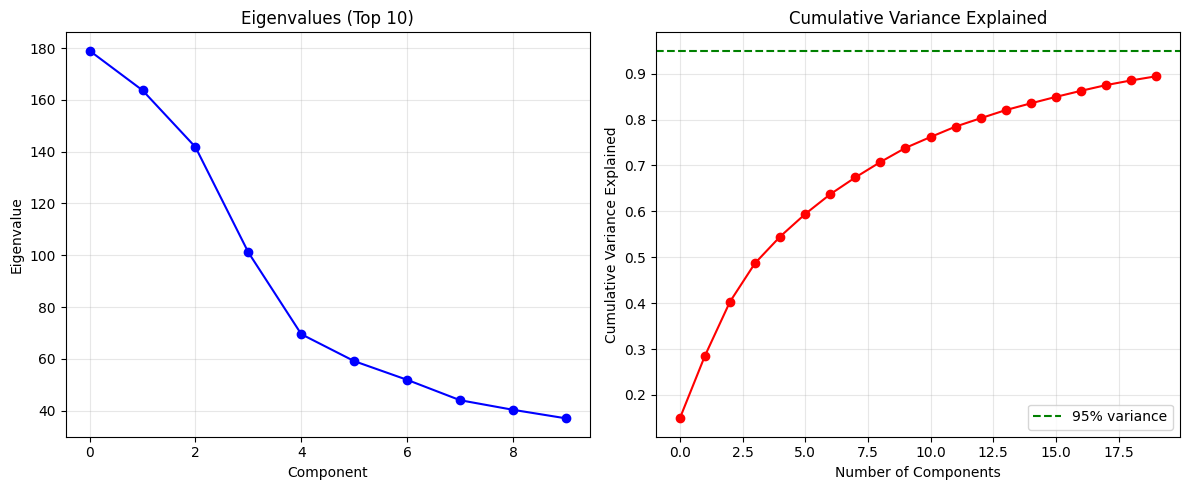


Number of components to explain 95% variance: 29 (out of 64 original pixels)

✅ Eigenvalue analysis applied to ML dimensionality reduction!


In [5]:
# ML payoff: hand the same job to sklearn's PCA and read the eigenvalue/cumulative-variance plots
# to choose how many components keep 95% of the information.

print("\n" + "=" * 60)
print("Part 3: Application to ML Problems")
print("=" * 60)

# Example: Using PCA (which uses eigenvalue decomposition internally)
print("\nPCA for Dimensionality Reduction:")
print("-" * 60)

# Apply PCA
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X)

print(f"\nReduced data shape: {X_pca.shape}  (from {X.shape[1]} pixels down to 10 components)")
print(f"Variance explained by 10 components: {pca.explained_variance_ratio_.sum():.4f}")

# Visualize eigenvalues
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(eigenvalues[:10], 'bo-')
plt.xlabel('Component')
plt.ylabel('Eigenvalue')
plt.title('Eigenvalues (Top 10)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(cumulative_variance[:20], 'ro-')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('Cumulative Variance Explained')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Number of components to explain 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nNumber of components to explain 95% variance: {n_components_95} "
      f"(out of {X.shape[1]} original pixels)")

print("\n✅ Eigenvalue analysis applied to ML dimensionality reduction!")

---

## ⚠️ Where this breaks

- **"Large" in this notebook means 200×200.** `eigh` returned in about 2 ms. Eigendecomposition costs on the
  order of n³, so a 20,000×20,000 covariance matrix is roughly a million times more work and needs 3.2 GB
  just to store in float64. Past a few thousand features you must not form the covariance matrix at all —
  you run a truncated or randomized SVD on the data matrix directly.
- **`eigh` is faster because it assumes symmetry, and it does not check.** Hand it a non-symmetric matrix
  and it will read one triangle, ignore the other, and return confident nonsense. The notebook prints
  `max|G − Gᵀ| = 0.00e+00` before using it; that line is not decoration.
- **Variance explained is not accuracy.** Ten components kept 73.8% of the variance of the digit images, and
  29 of 64 were needed for 95%. Neither number tells you whether a classifier built on those components can
  read handwriting. That is a separate experiment — and Unit 4, notebook 03 shows a case on real data where
  dropping features *lowered* accuracy. The assumption smuggled into "variance explained" is that the
  directions your data varies most along are the directions your label depends on. Often true. Not a theorem.


---

## 💬 Discuss

1. `eigh` beat `eig` by about 7× purely by being told the matrix is symmetric, and it verifies nothing.
   What is the general lesson about declaring what you know to your tools — and what risk do you take on
   the moment you do?
2. Twenty-nine of 64 components for 95% of the variance is a 2.2× compression, not the 10× a textbook
   example implies. Would you ship it? Name the evidence you would want first, and say who carries the cost
   if you are wrong.
3. Suppose the 8×8 digit images were 1024×1024 medical scans instead, so the covariance matrix is
   1,048,576 × 1,048,576. Which line of this notebook breaks first, and what would you do instead?


## Summary

### Key Concepts:
1. **Eigenvalue Decomposition**: Breaking down matrices into eigenvalues and eigenvectors
2. **Symmetric Matrices**: Have real eigenvalues and orthogonal eigenvectors
3. **Numerical Methods**: Use `eigh()` for symmetric matrices (more efficient than `eig()`)
4. **PCA and Eigenvalues**: Principal Component Analysis uses eigenvalue decomposition
5. **Dimensionality Reduction**: Eigenvalues determine importance of components

### Best Practices:
- Use `scipy.linalg.eigh()` for symmetric matrices (faster, more stable)
- Verify decomposition: Av = λv
- Sort eigenvalues by magnitude for dimensionality reduction
- Use cumulative variance to select number of components

### Applications:
- Principal Component Analysis (PCA)
- Dimensionality reduction
- Data compression
- Feature extraction
- Understanding data structure

**Reference:** Course 03, Unit 1: "Linear Algebra for Machine Learning" - Eigenvalue analysis on large-dimensional matrices practical content

## 📚 References

1. Halko, N., Martinsson, P.-G., & Tropp, J. A. (2011). *Finding Structure with Randomness: Probabilistic Algorithms for Constructing Approximate Matrix Decompositions*. SIAM Review, 53(2), 217–288. <https://arxiv.org/abs/0909.4061>
2. Jolliffe, I. T., & Cadima, J. (2016). *Principal Component Analysis: A Review and Recent Developments*. Philosophical Transactions of the Royal Society A, 374(2065). <https://doi.org/10.1098/rsta.2015.0202>
3. Deisenroth, M. P., Faisal, A. A., & Ong, C. S. (2020). *Mathematics for Machine Learning*, Ch. 4: Matrix Decompositions. Cambridge University Press. <https://mml-book.github.io/>
4. Dereziński, M., & Mahoney, M. W. (2024). *Recent and Upcoming Developments in Randomized Numerical Linear Algebra for Machine Learning*. arXiv. <https://arxiv.org/abs/2406.11151> — the current state of randomized linear algebra for exactly the large-matrix problems in this notebook.
5. Pearce, K. J., & Martinsson, P.-G. (2025). *Randomized Algorithms for Low-Rank Matrix and Tensor Decompositions*. arXiv. <https://arxiv.org/abs/2512.05286> — randomized algorithms for low-rank matrix and tensor decompositions, 2025.
